Hypergraph codes are H1 = H2

and Hx = (H1 dot I2T, I1 dot H2T)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import pymatching

[[1 0 0 1 0 0 0 0 0 1 0 0 0]
 [0 1 0 0 1 0 0 0 0 1 1 0 0]
 [0 0 1 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 1 0 0 0 1 1]
 [0 0 0 0 0 1 0 0 1 0 0 0 1]]
[[1 1 0 0 0 0 0 0 0 1 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 1 1 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 0 1 1 0 0 0 1]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


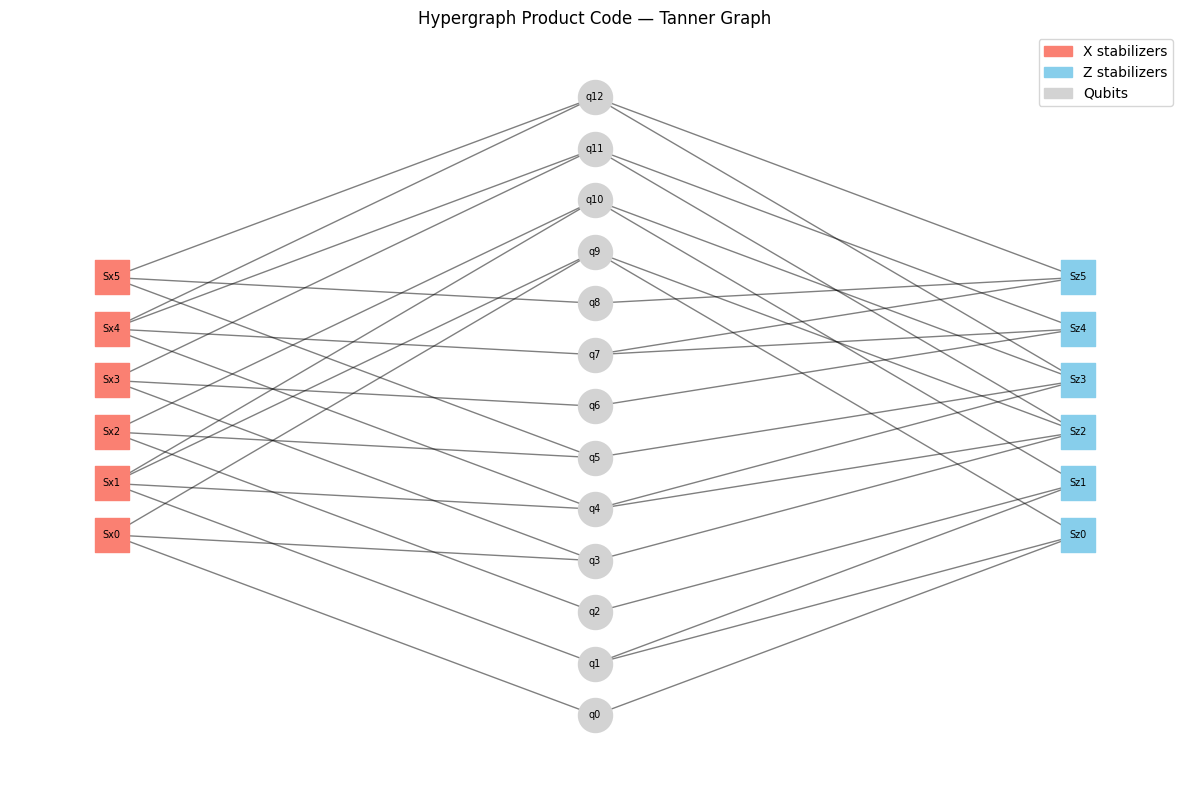

In [2]:
def repetition_code(n):
    H = np.zeros((n-1, n), dtype=int)
    for i in range(n-1):
        H[i, i]   = 1
        H[i, i+1] = 1
    return H

H1 = repetition_code(3)
H2 = repetition_code(3)
H2T = H2.T
r1, n1 = H1.shape
r2, n2 = H2.shape
I2T = np.eye(n2, dtype=int) #identity matrix in the shape of the rows of H1 or H2
I1 = np.eye(r1, dtype=int) #identity matrix in the shape of the columns of H1 or H2

def hypergraphHxHz(H1, H2T, I1, I2T):
    """
    Args:
        H1 (array?): 3 bit code thing
        H2 (_type_): same as above
        I1 (_type_): identity matrix 
        I2T (_type_): identity matrix

    Returns: 
        Hx, Hz for hypergraph codes
    """
    Hxr = np.kron(H1, I2T)
    Hxl= np.kron(I1, H2T)
    Hx = np.hstack([Hxr, Hxl])

    Hzr = np.kron(I2T, H1)
    Hzl = np.kron(H2T, I1)
    Hz = np.hstack([Hzr, Hzl])
    return Hx, Hz

Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T) #this gives a list of which stabilisers (rows) touch which qubits (columns)
#print(I2T)
print(Hx)
print(Hz)

def verify_HxHz(Hx, Hz):
    """
    Args:
        Hx (_type_): a matrix to show where the X type stabilisers connect
        Hz (_type_): a matrix to show where the Z type stabilisers connect

    Return:
        Hx dot Hz^T
    """
    return (Hx @ Hz.T) % 2 # do np.dot but in mod 2 GF2

print(verify_HxHz(Hx, Hz))

def tanner_image(Hx, Hz):
    """
    Args:
        Hx (_type_): a matrix to show where the X type stabilisers connect
        Hz (_type_): a matrix to show where the Z type stabilisers connect

    Returns:
        image of surface code
    """
    G = nx.Graph()
    n_qubits = Hx.shape[1]
    
    qubit_nodes = [f"q{i}"  for i in range(n_qubits)]
    Sx_nodes = [f"Sx{i}" for i in range(Hx.shape[0])]
    Sz_nodes = [f"Sz{i}" for i in range(Hz.shape[0])]

    # makes all the qubits and spabilisers appear
    G.add_nodes_from(qubit_nodes, bipartite = 0)
    G.add_nodes_from(Sx_nodes, bipartate = 1)
    G.add_nodes_from(Sz_nodes, bipartate = 2)

    #connections between them
    for i, row in enumerate(Hx):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sx{i}", f"q{j}")
    for i, row in enumerate(Hz):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sz{i}", f"q{j}")
        
    pos= {}
    for i, n in enumerate(Sx_nodes):
        pos[n] = (-2, i -len(Sx_nodes)/2)
    for i, n in enumerate(qubit_nodes):
        pos[n] = (0, i -len(qubit_nodes)/2)
    for i, n in enumerate(Sz_nodes):
        pos[n] = (2, i -len(Sz_nodes)/2)

    fig, ax = plt.subplots(figsize = (12,8))
    nx.draw_networkx_nodes(G, pos, nodelist= qubit_nodes, node_shape="o", node_color="lightgrey", node_size=600, ax=ax) 
    nx.draw_networkx_nodes(G, pos, nodelist= Sx_nodes, node_shape="s", node_color="salmon", node_size=600, ax=ax) 
    nx.draw_networkx_nodes(G, pos, nodelist= Sz_nodes, node_shape="s", node_color="skyblue", node_size=600, ax=ax) 
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5) 

    legend = [mpatches.Patch(color="salmon",    label="X stabilizers"),
              mpatches.Patch(color="skyblue",   label="Z stabilizers"),
              mpatches.Patch(color="lightgrey", label="Qubits")]
    ax.legend(handles=legend)
    ax.set_title("Hypergraph Product Code — Tanner Graph")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

tanner_image(Hx, Hz)

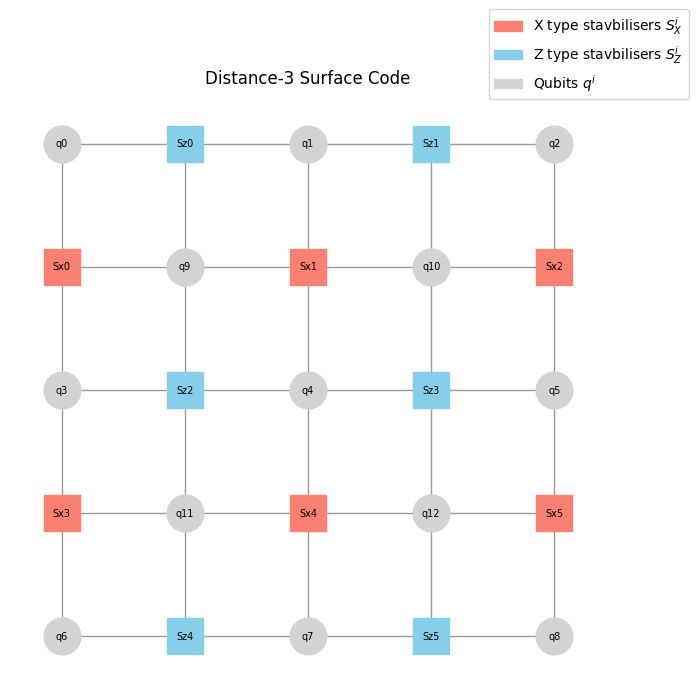

In [3]:
#make the surafec code
#need a grid
#have the correct nodes between things to yay!

def surface_code_image(Hx, Hz):
    """_summary_

    Args:
        Hx (_type_): tells you where Sx connect
        HZ (_type_): matrix of Sz connections
    
    Returns: 
        Surface code diagram
    """
    
    G = nx.Graph()
    d = 3 # bc using H=H1+H2 w distance 3
    
    #same labels as in tanner graph function - should i make it a seperate function to call in both?
    n_qubits = Hx.shape[1]
    qubit_nodes = [f"q{i}"  for i in range(n_qubits)]
    Sx_nodes = [f"Sx{i}" for i in range(Hx.shape[0])]
    Sz_nodes = [f"Sz{i}" for i in range(Hz.shape[0])]
    
    G.add_nodes_from(qubit_nodes)
    G.add_nodes_from(Sx_nodes)
    G.add_nodes_from(Sz_nodes)

    for i, row in enumerate(Hx):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sx{i}", f"q{j}")
    for i, row in enumerate(Hz):
        for j, val in enumerate(row):
            if val: G.add_edge(f"Sz{i}", f"q{j}")
    
    pos = {
        # Row 4 (top)
        "q0":  (0, 4), "Sz0": (1, 4), "q1":  (2, 4), "Sz1": (3, 4), "q2":  (4, 4),
        # Row 3
        "Sx0": (0, 3), "q9":  (1, 3), "Sx1": (2, 3), "q10": (3, 3), "Sx2": (4, 3),
        # Row 2
        "q3":  (0, 2), "Sz2": (1, 2), "q4":  (2, 2), "Sz3": (3, 2), "q5":  (4, 2),
        # Row 1
        "Sx3": (0, 1), "q11": (1, 1), "Sx4": (2, 1), "q12": (3, 1), "Sx5": (4, 1),
        # Row 0 (bottom)
        "q6":  (0, 0), "Sz4": (1, 0), "q7":  (2, 0), "Sz5": (3, 0), "q8":  (4, 0),
    }
    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_nodes(G, pos, nodelist=qubit_nodes, node_shape="o",
                           node_color="lightgrey", node_size=700, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=Sx_nodes, node_shape="s",
                           node_color="salmon",    node_size=700, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=Sz_nodes, node_shape="s",
                           node_color="skyblue",   node_size=700, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4)

    legend = [mpatches.Patch(color="salmon",    label="X type stavbilisers $S_X^i$"),
              mpatches.Patch(color="skyblue",   label="Z type stavbilisers $S_Z^i$"),
              mpatches.Patch(color="lightgrey", label="Qubits $q^i$")]
    ax.legend(handles=legend, loc="upper right", bbox_to_anchor=(1.15, 1.15))
    ax.set_title(f"Distance-{d} Surface Code")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

surface_code_image(Hx, Hz)

Logical Z weight: 3
Hx · logical_z mod 2: [0 0 0 0 0 0]


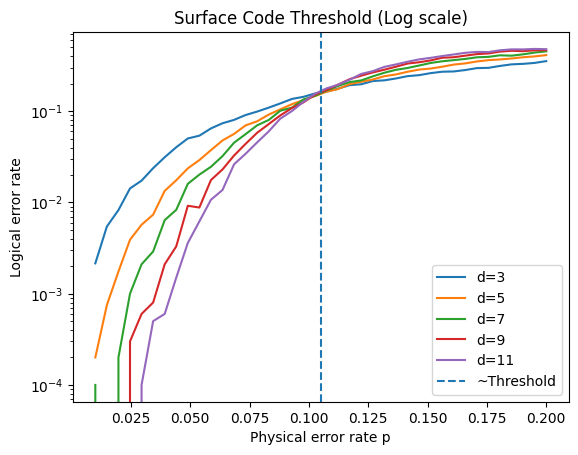

In [4]:
def get_logical_z(d):
    r = d - 1  # rows of H
    n = d      # cols of H
    n_top = n * n        # = d²
    n_bot = r * r        # = (d-1)²
    n_qubits = n_top + n_bot

    logical = np.zeros(n_qubits, dtype=np.uint8)
    # Logical Z = first column of top block in the I_n ⊗ H layout
    # = qubits 0, n, 2n, ... (stride n through top block)
    for i in range(n):
        logical[i * n] = 1
    return logical

#hypergraph lin alg - tutorial pat 7?

# checks 
d = 3
Hx, Hz = hypergraphHxHz(H1, H2T, I1, I2T)
logical_z = get_logical_z(d)
# codewords of Hz 
print("Logical Z weight:", logical_z.sum())
# should be zeros
print("Hx · logical_z mod 2:", (Hx @ logical_z) % 2)  

def get_surface_code_matching(Hz, d):
    return pymatching.Matching.from_check_matrix(Hz)

def logical_error_rate(Hz, d, p, shots):
    matcher = get_surface_code_matching(Hz, d)
    n_qubits = Hz.shape[1]
    failures = 0

    for _ in range(shots):
        # errors on qubits
        error = (np.random.rand(n_qubits) < p).astype(np.uint8)

        # syndrome value 
        syndrome = (Hz @ error) % 2

        # decode w risidual thing
        correction = matcher.decode(syndrome)

        # if in logical set its an error if stab set its not
        logical_z = get_logical_z(d)
        residual = (error ^ correction) & logical_z
        if residual.sum() % 2 == 1:
            failures += 1

    return failures / shots


#run
ps = np.linspace(0.01, 0.2, 40) 
distances = [3, 5, 7, 9, 11]
shots_by_d = {3: 20000, 5: 20000, 7: 10000, 9: 10000, 11: 10000}  # more shots for small d

#plot
for d in distances:
    H = repetition_code(d)
    HT = H.T
    r, n = H.shape
    I_n = np.eye(n, dtype=int)
    I_r = np.eye(r, dtype=int)
    _, Hz = hypergraphHxHz(H, HT, I_r, I_n)
    Hz = Hz % 2

    rates = [logical_error_rate(Hz, d, p, shots_by_d[d]) for p in ps]
    plt.plot(ps, rates, label=f"d={d}")

plt.axvline(0.105, linestyle='--', label="~Threshold")
plt.xlabel("Physical error rate p")
plt.yscale("log")
plt.ylabel("Logical error rate")
plt.legend()
plt.title("Surface Code Threshold (Log scale)")
plt.show()

#log scale for y axiz looks better
#exponential supression